# BSM 方程与 Greeks

本节基于 BSM 方程计算期权价格与五个希腊量（Delta、Gamma、Vega、Theta、Rho），
并通过统一的绘图入口 `plot_greeks` 扫描各个参数，观察希腊量的性质与规律。


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from derivlab import (
    bsm_delta,
    bsm_gamma,
    bsm_price,
    bsm_rho,
    bsm_theta,
    bsm_vega,
)

# 基线参数，沿用 Hull 教材示例，便于对照
S, K, T, r, sigma, q = 42.0, 40.0, 0.5, 0.10, 0.20, 0.0

# 五个希腊量的函数入口
funcs = {
    "delta": bsm_delta,
    "gamma": bsm_gamma,
    "vega": bsm_vega,
    "theta": bsm_theta,
    "rho": bsm_rho,
}

# 面板定义：价格 + 五个希腊量
panels = [
    ("price", "Option Price"),
    ("delta", "Delta"),
    ("gamma", "Gamma"),
    ("vega", "Vega"),
    ("theta", "Theta"),
    ("rho", "Rho"),
]


def plot_greeks(param, values, xlabel, title):
    """统一的敏感性绘图入口：扫描某个参数，画出价格 + 五个希腊量。

    Args:
        param: 待扫描的参数名（"S"/"K"/"T"/"r"/"sigma"/"q"）
        values: 参数取值数组
        xlabel: x 轴标签
        title: 图标题
    """
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
    fig.suptitle(title, fontsize=13)

    for ax, (name, sub_title) in zip(axes.flat, panels):
        kwargs = {"S": S, "K": K, "T": T, "r": r, "sigma": sigma, "q": q}
        kwargs[param] = values

        if name == "price":
            ax.plot(values, bsm_price(**kwargs, option_type="call"), label="call")
            ax.plot(values, bsm_price(**kwargs, option_type="put"), label="put")
        elif name in ("gamma", "vega"):
            ax.plot(values, funcs[name](**kwargs), label="call/put", color="tab:green")
        else:
            ax.plot(values, funcs[name](**kwargs, option_type="call"), label="call")
            ax.plot(values, funcs[name](**kwargs, option_type="put"), label="put")

        ax.axhline(0, color="black", lw=0.6, alpha=0.5)
        ax.set_title(sub_title)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    for ax in axes[1]:
        ax.set_xlabel(xlabel)
    fig.tight_layout()
    plt.show()


## 基线数值

基于教材的基线参数，计算每个希腊量在 call / put 下的取值。

In [2]:
rows = [
    (
        "price",
        bsm_price(S, K, T, r, sigma, "call", q),
        bsm_price(S, K, T, r, sigma, "put", q),
    )
]
for name, f in funcs.items():
    if name in ("gamma", "vega"):
        # gamma/vega 对 call/put 完全相同，函数不接收 option_type
        val = f(S, K, T, r, sigma, q)
        rows.append((name, val, val))
    else:
        rows.append(
            (name, f(S, K, T, r, sigma, "call", q), f(S, K, T, r, sigma, "put", q))
        )

greeks_table = (
    pd.DataFrame(rows, columns=["greeks", "call", "put"]).set_index("greeks").round(6)
)
greeks_table


,call,put
greeks,,
price,4.759422,0.808599
delta,0.779131,-0.220869
gamma,0.049963,0.049963
vega,8.813415,8.813415
theta,-4.559092,-0.754174
rho,13.982046,-5.042543


从公式不难看出：**Gamma 和 Vega 对看涨/看跌期权完全相同**，因此下面各图中它们用同一条曲线（绿色）表示。

## Greeks vs S

下面来看希腊量与标的价格 S 的关系。

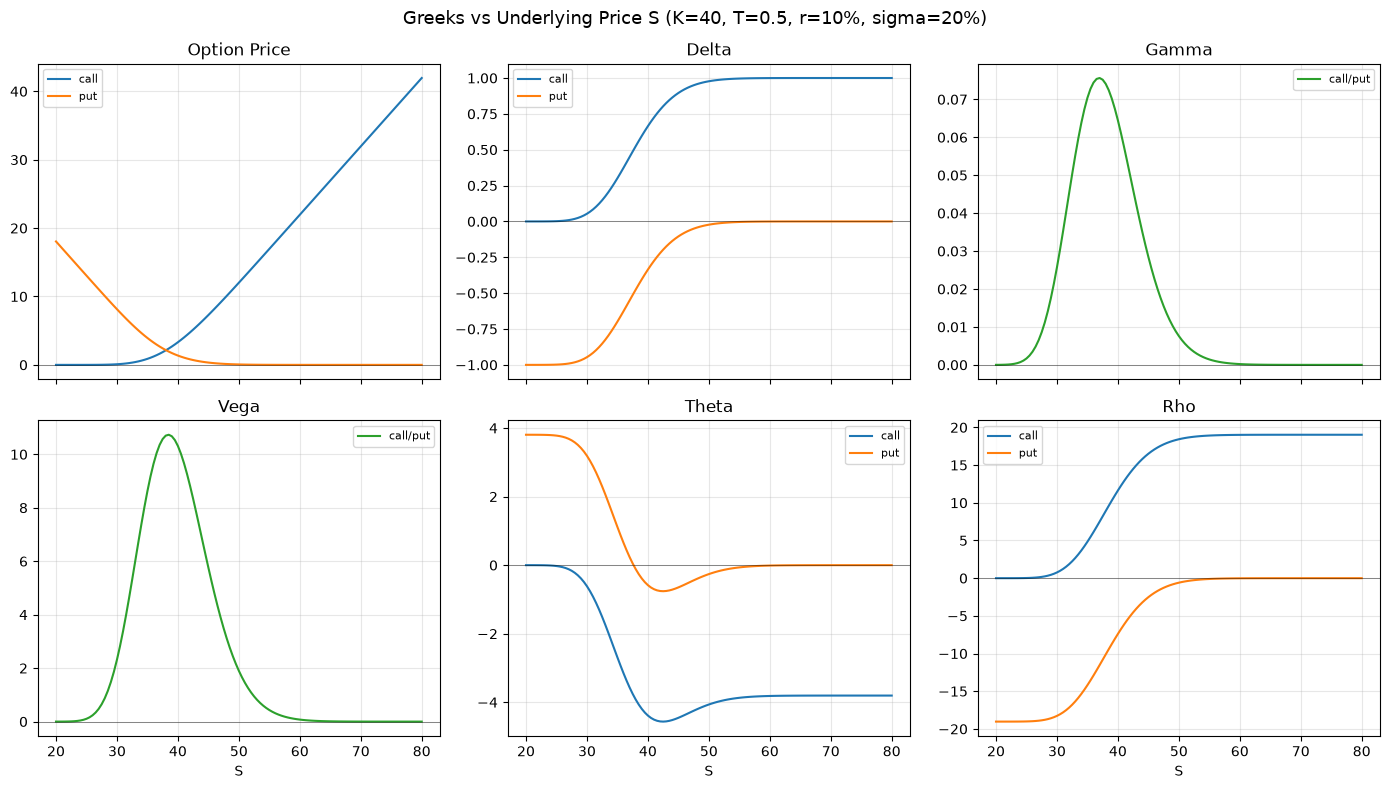

In [3]:
plot_greeks("S", np.linspace(20, 80, 121), "S",
            "Greeks vs Underlying Price S (K=40, T=0.5, r=10%, sigma=20%)")


## Greeks vs T

下面来看希腊量与到期时间 T 的关系。

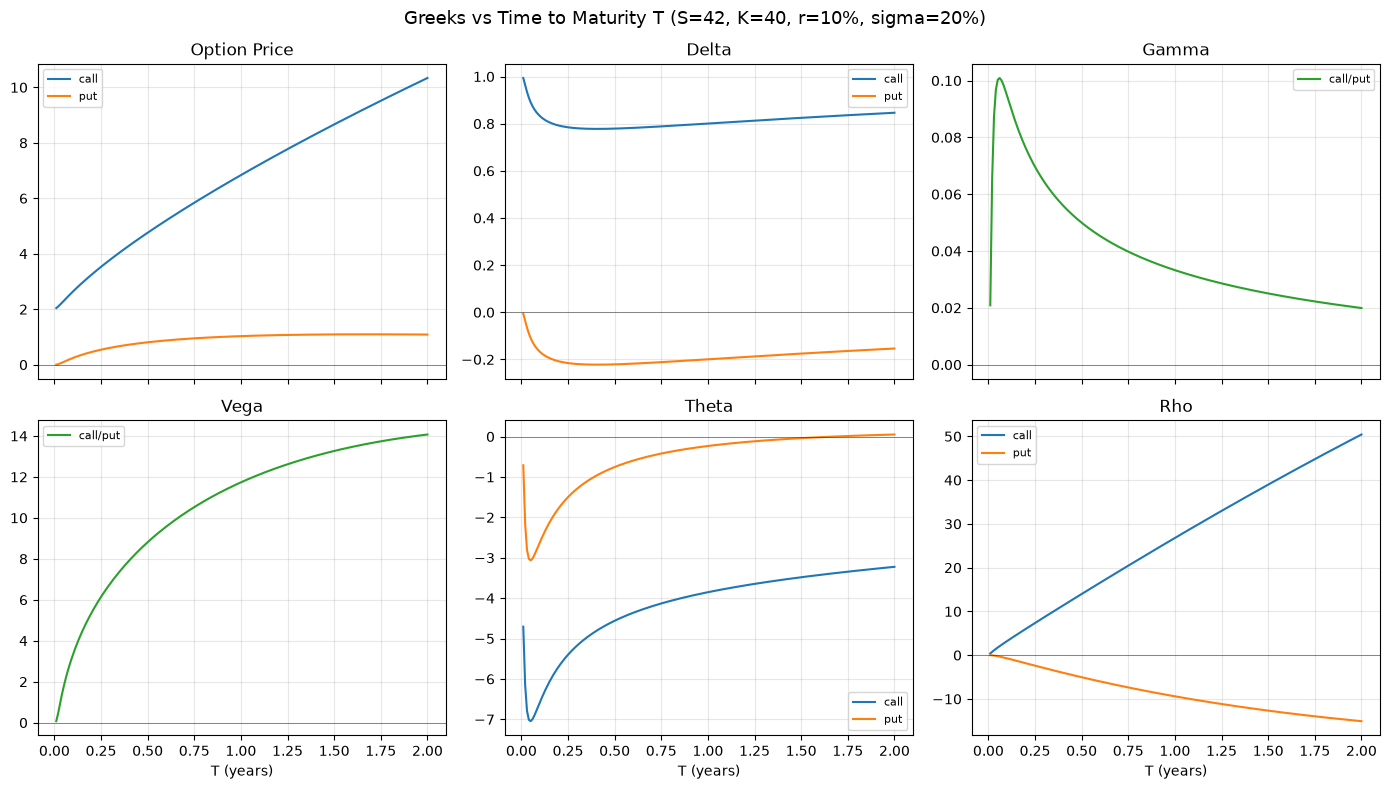

In [4]:
plot_greeks("T", np.linspace(0.01, 2.0, 200), "T (years)",
            "Greeks vs Time to Maturity T (S=42, K=40, r=10%, sigma=20%)")


## Greeks vs sigma

下面来看希腊量随波动率 σ 的变化。

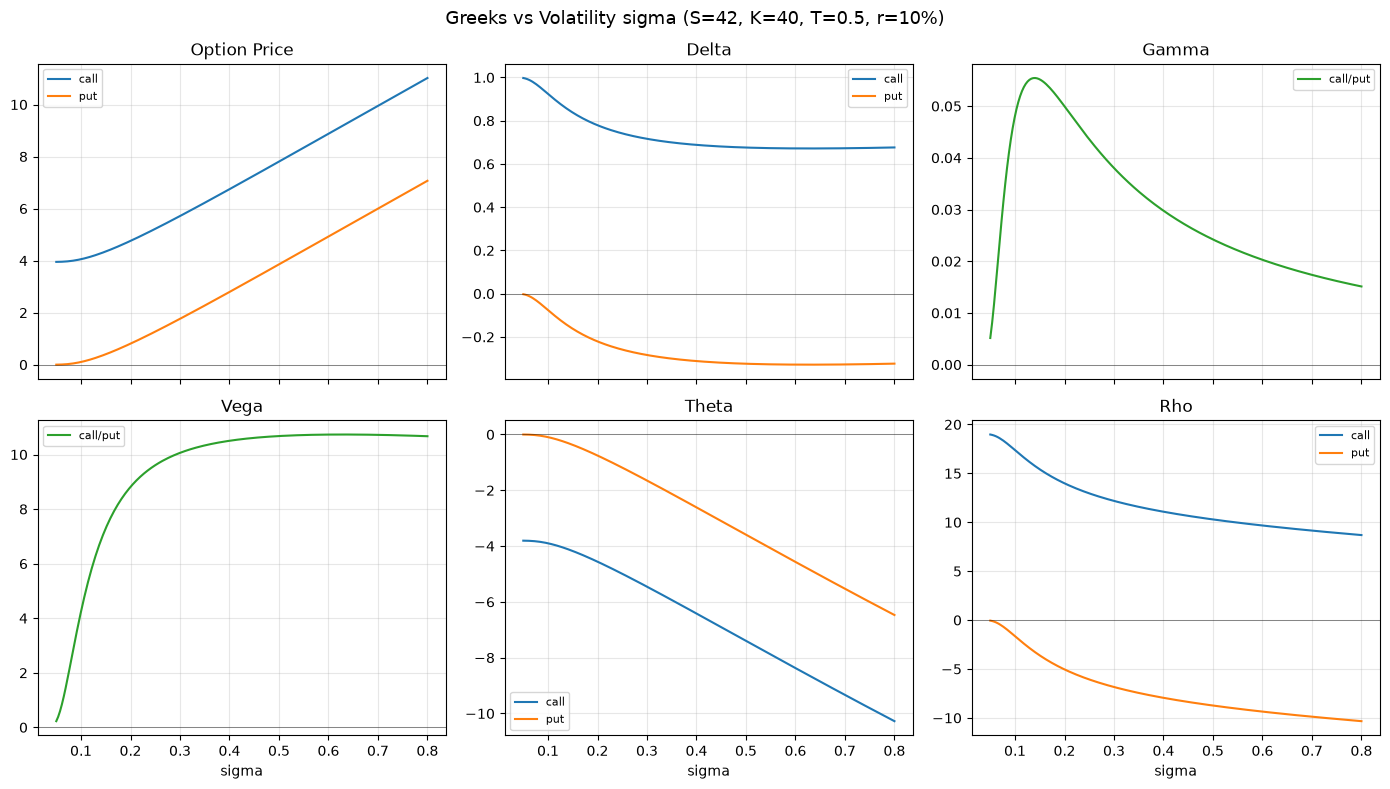

In [5]:
plot_greeks("sigma", np.linspace(0.05, 0.8, 200), "sigma",
            "Greeks vs Volatility sigma (S=42, K=40, T=0.5, r=10%)")


## Greeks vs K

最后，看希腊量与行权价的关系。

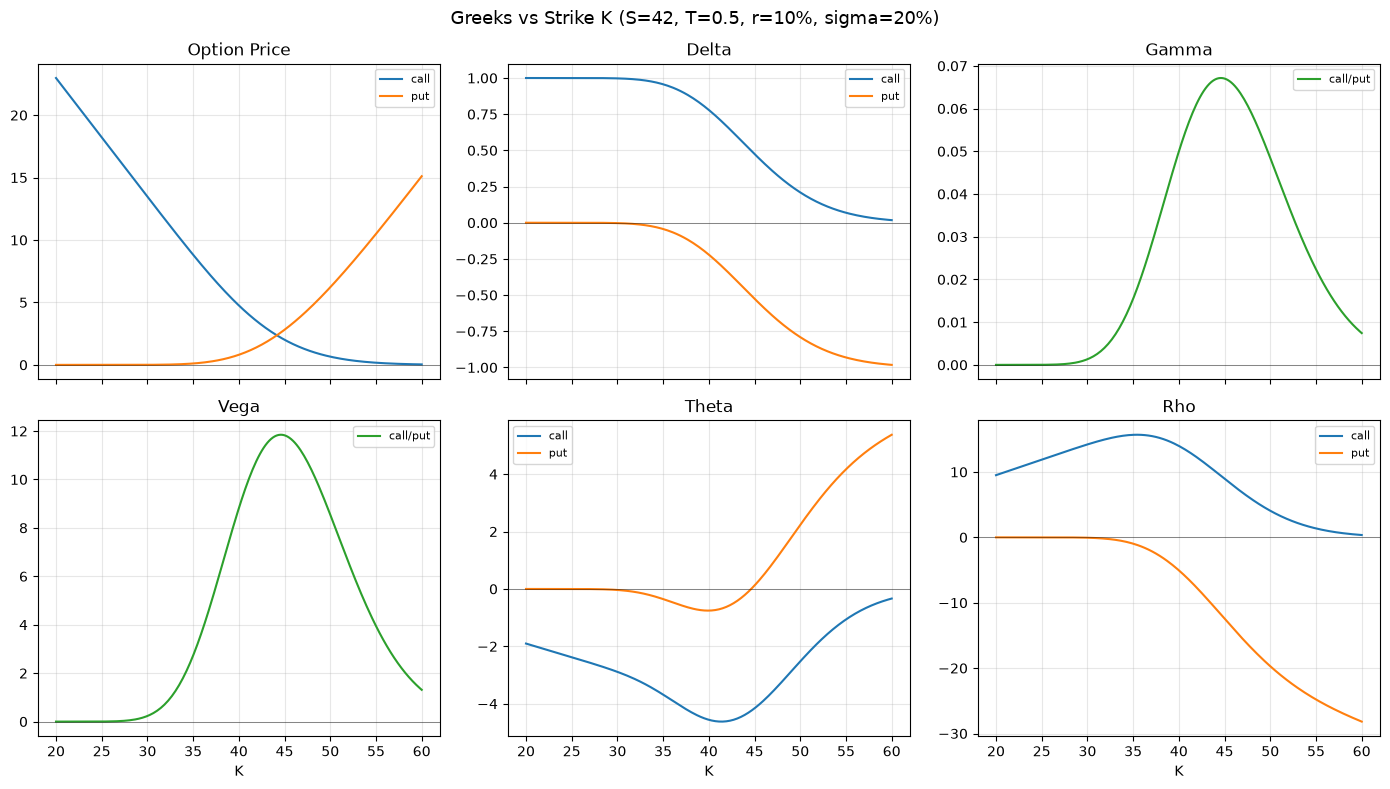

In [6]:
plot_greeks("K", np.linspace(20, 60, 200), "K",
            "Greeks vs Strike K (S=42, T=0.5, r=10%, sigma=20%)")


## Greeks vs r

最后，看希腊量与利率的关系。

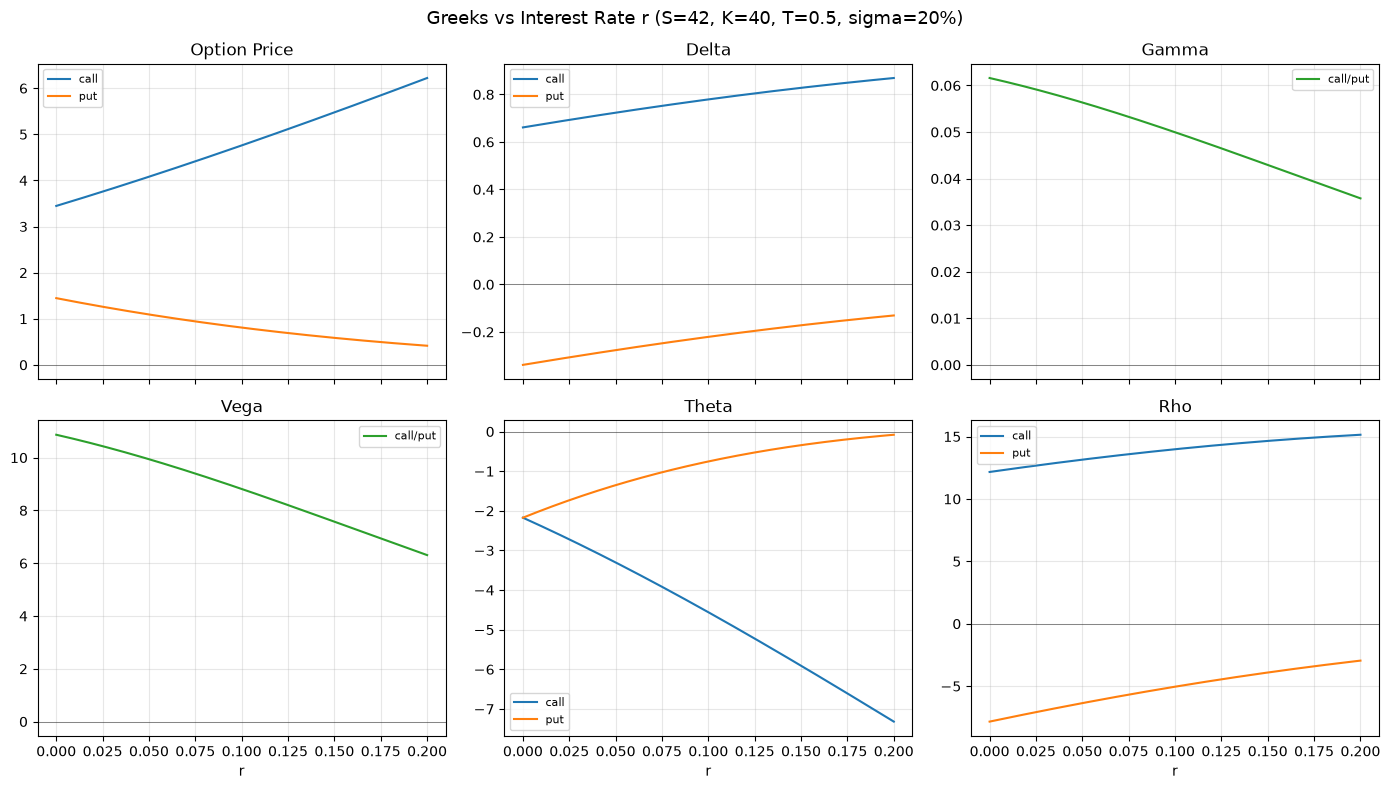

In [7]:
plot_greeks("r", np.linspace(0.00, 0.20, 200), "r",
            "Greeks vs Interest Rate r (S=42, K=40, T=0.5, sigma=20%)")


## Greeks vs q

最后，看希腊量与股息率的关系。

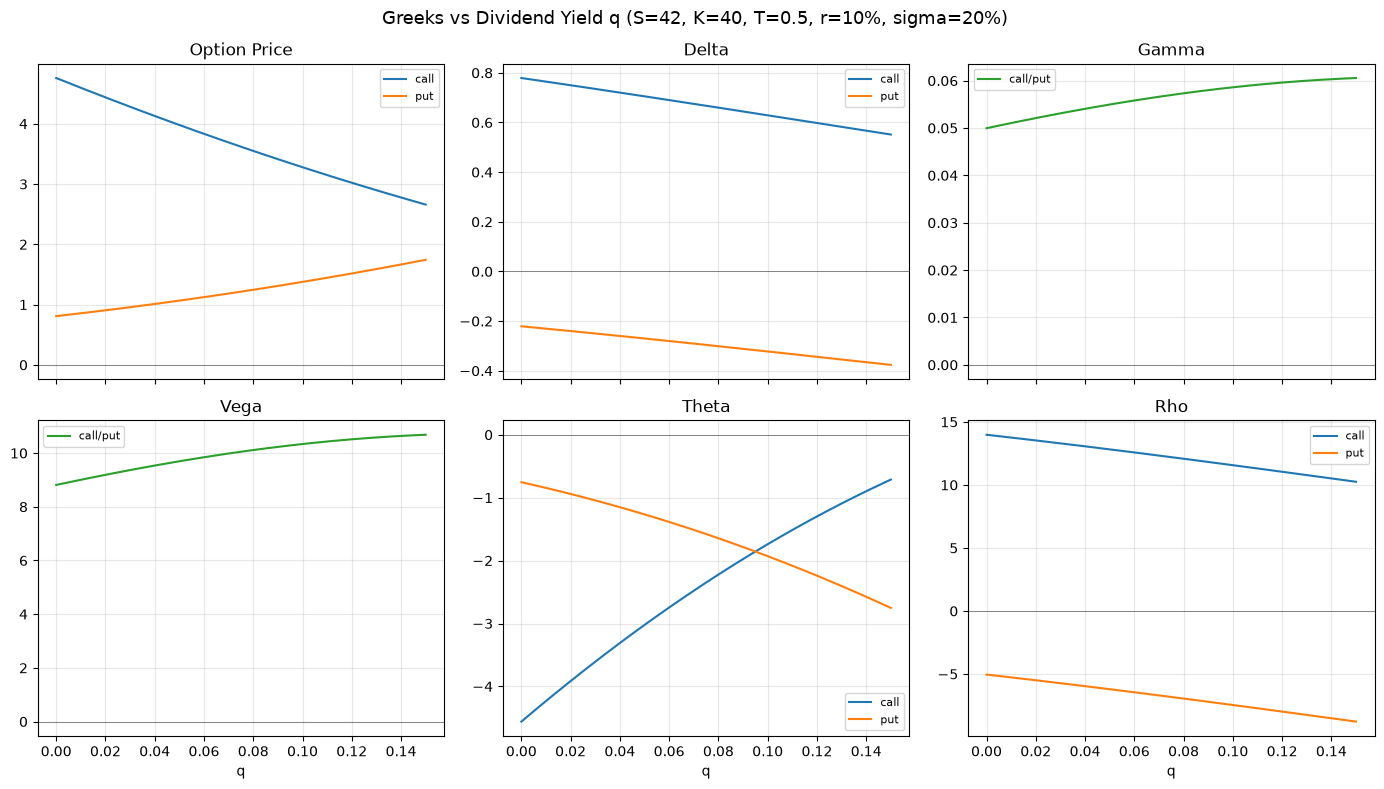

In [8]:
plot_greeks("q", np.linspace(0.00, 0.15, 200), "q",
            "Greeks vs Dividend Yield q (S=42, K=40, T=0.5, r=10%, sigma=20%)")


## 观察总结

- **Delta**：call 在 [0, 1]、put 在 [-1, 0] 之间单调变化，平值附近最陡；对波动率的响应方向取决于实值/虚值（实值 call 的 delta 随 σ 升高而下降，虚值则相反）。
- **Gamma / Vega**：call 与 put 完全相同；两者都在平值（S≈K）附近取极大，向实值/虚值两侧衰减。
- **Theta**：通常为负（时间衰减），平值附近最负；随到期临近，平值期权的 gamma 发散、theta 发散（相伴出现）。
- **Rho**：call 为正、put 为负，随到期时间大致线性增大。
- **r 与 q 的作用相反**：利率抬升远期、利好 call；股息率压低远期、利好 put。

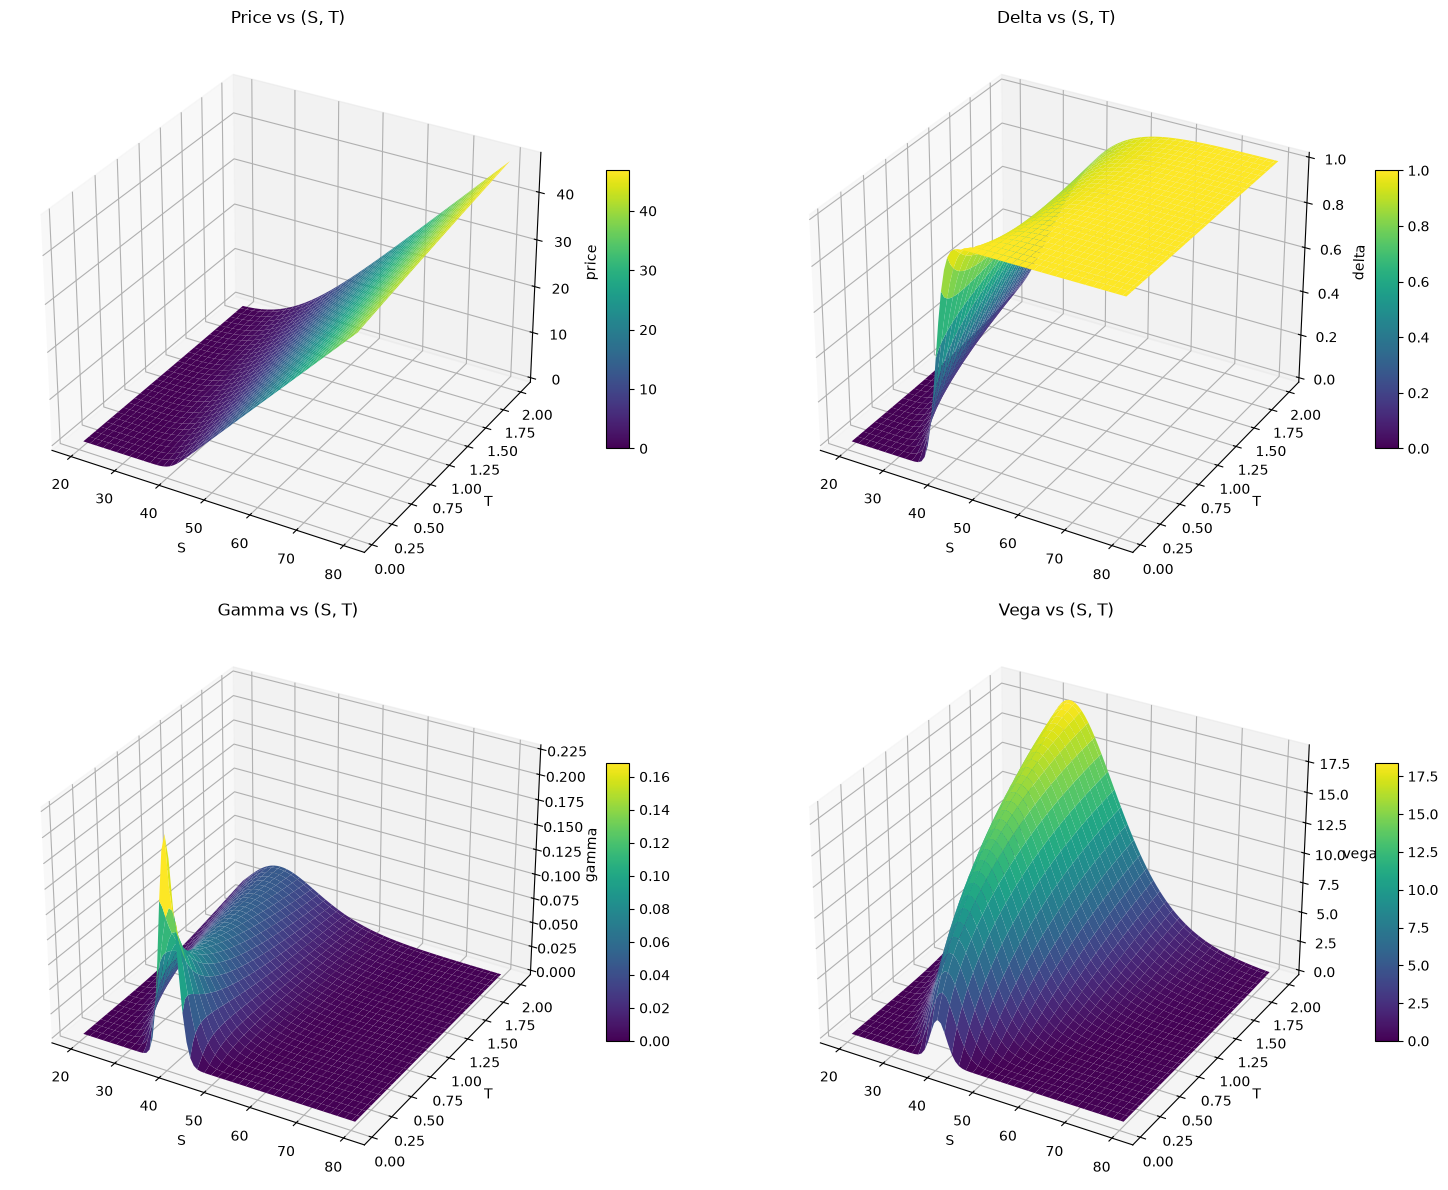

In [9]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

S_grid = np.linspace(20, 80, 80)
T_grid = np.linspace(0.05, 2.0, 60)
S_mesh, T_mesh = np.meshgrid(S_grid, T_grid)

surfaces = [
    ("price", bsm_price(S_mesh, K, T_mesh, r, sigma, "call", q)),
    ("delta", bsm_delta(S_mesh, K, T_mesh, r, sigma, "call", q)),
    ("gamma", bsm_gamma(S_mesh, K, T_mesh, r, sigma, q)),
    ("vega", bsm_vega(S_mesh, K, T_mesh, r, sigma, q)),
]

fig = plt.figure(figsize=(16, 12))
for i, (name, Z) in enumerate(surfaces, start=1):
    ax = fig.add_subplot(2, 2, i, projection="3d")
    surf = ax.plot_surface(S_mesh, T_mesh, Z, cmap="viridis", linewidth=0, antialiased=True)
    ax.set_xlabel("S")
    ax.set_ylabel("T")
    ax.set_zlabel(name)
    ax.set_title(f"{name.capitalize()} vs (S, T)")
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=12)
fig.tight_layout()
plt.show()

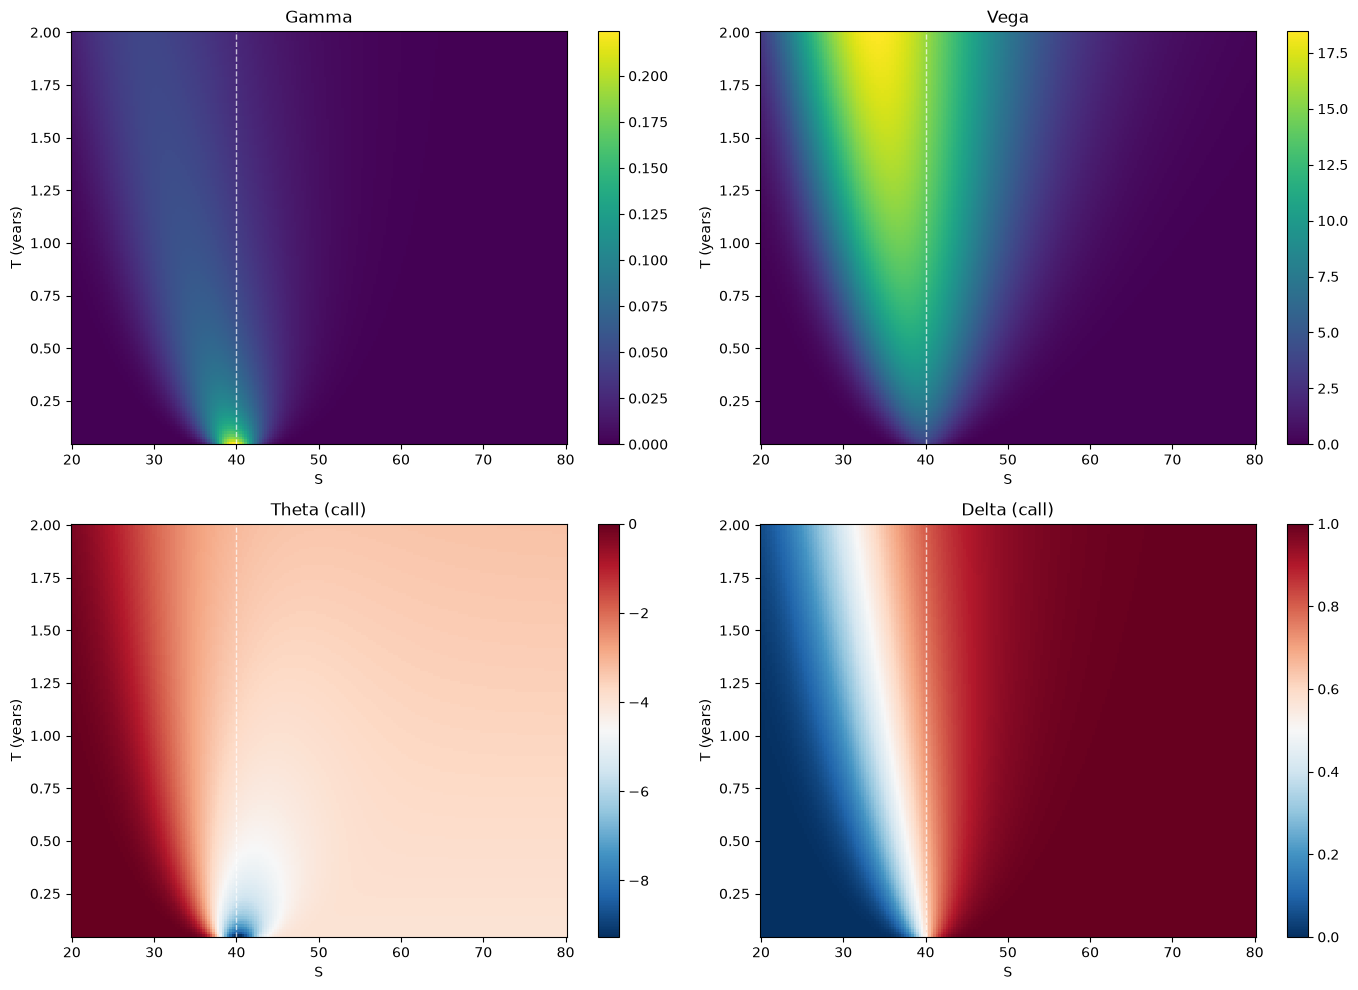

In [10]:
S_grid = np.linspace(20, 80, 200)
T_grid = np.linspace(0.05, 2.0, 160)
S_mesh, T_mesh = np.meshgrid(S_grid, T_grid)

heatmaps = [
    ("Gamma", bsm_gamma(S_mesh, K, T_mesh, r, sigma, q), "viridis"),
    ("Vega", bsm_vega(S_mesh, K, T_mesh, r, sigma, q), "viridis"),
    ("Theta (call)", bsm_theta(S_mesh, K, T_mesh, r, sigma, "call", q), "RdBu_r"),
    ("Delta (call)", bsm_delta(S_mesh, K, T_mesh, r, sigma, "call", q), "RdBu_r"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, Z, cmap) in zip(axes.flat, heatmaps):
    im = ax.pcolormesh(S_grid, T_grid, Z, shading="auto", cmap=cmap)
    ax.axvline(K, color="white", ls="--", lw=1.0, alpha=0.7)
    ax.set_xlabel("S")
    ax.set_ylabel("T (years)")
    ax.set_title(name)
    fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()